In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

In [2]:
baseline_df = pd.read_csv(
    "../experiments/comparison/baseline_results.csv"
)

pca_df = pd.read_csv(
    "../experiments/comparison/pca_results.csv"
)

lda_df = pd.read_csv(
    "../experiments/comparison/lda_results.csv"
)

pca_lda_knn_df = pd.read_csv(
    "../experiments/comparison/pca_lda_knn_results.csv"
)

pca_lda_nn_df = pd.read_csv(
    "../experiments/comparison/pca_lda_nn_results.csv"
)

knn_tuning_df = pd.read_csv(
    "../experiments/comparison/knn_hyperparameter_results.csv"
)

nn_tuning_df = pd.read_csv(
    "../experiments/comparison/nn_hyperparameter_results.csv"
)

In [9]:
print("Baseline:")
display(baseline_df.head())

print("\nPCA:")
display(pca_df.head())

print("\nLDA:")
display(lda_df.head())

print("\nPCA + LDA KNN:")
display(pca_lda_knn_df.head())

print("\nPCA + LDA Neural Network:")
display(pca_lda_nn_df.head())

print("\nKNN Hyperparameter:")
display(knn_tuning_df.head())

print("\nNeural Network Hyperparameter:")
display(nn_tuning_df.head())

Baseline:


,Unnamed: 0,Accuracy,Precision,Recall,F1
0,KNN,0.925009,0.938876,0.935406,0.937091
1,Neural Network,0.933875,0.945793,0.943841,0.944792



PCA:


,Unnamed: 0,Accuracy,Precision,Recall,F1
0,KNN + PCA(2),0.859993,0.854555,0.851962,0.853106
1,KNN + PCA(4),0.888437,0.892038,0.887428,0.889034
2,KNN + PCA(6),0.926487,0.940418,0.937039,0.938658
3,KNN + PCA(8),0.925009,0.938876,0.935406,0.937091
4,KNN + PCA(10),0.925009,0.938876,0.935406,0.937091



LDA:


...

,Unnamed: 0,Accuracy,Precision,Recall,F1
0,Neural Network + PCA(8) + LDA(2),0.854082,0.869329,0.858151,0.862622
1,Neural Network + PCA(8) + LDA(3),0.920946,0.932470,0.929628,0.930839
2,Neural Network + PCA(8) + LDA(4),0.921315,0.932675,0.931230,0.931852
3,Neural Network + PCA(8) + LDA(5),0.925748,0.937187,0.936038,0.936581
4,Neural Network + PCA(8) + LDA(6),0.931289,0.943255,0.941389,0.942286



KNN Hyperparameter:


,model,k,weights,Accuracy,Precision,Recall,F1
0,KNN,3,distance,0.919556,0.934234,0.932252,0.933181
1,KNN,3,uniform,0.919094,0.934157,0.932210,0.933105
2,KNN,5,uniform,0.920018,0.932818,0.931165,0.931874
3,KNN,5,distance,0.919556,0.932408,0.930825,0.931507
4,KNN,15,distance,0.918632,0.931050,0.928633,0.929461



Neural Network Hyperparameter:


,model,activation,learning_rate,batch_size,dropout_rate,Accuracy,Precision,Recall,F1
0,Neural Network,relu,0.010,64,0.2,0.924179,0.936172,0.933921,0.934866
1,Neural Network,relu,0.010,64,0.0,0.924179,0.934120,0.933595,0.933743
2,Neural Network,relu,0.010,32,0.2,0.922792,0.934474,0.931793,0.932882
3,Neural Network,relu,0.010,32,0.0,0.920018,0.931500,0.929760,0.930299
4,Neural Network,relu,0.001,32,0.0,0.914933,0.926988,0.924770,0.925608


In [10]:
baseline_comparison = baseline_df.copy()

baseline_comparison["Model"] = baseline_comparison["Unnamed: 0"]
baseline_comparison["Experiment"] = "Baseline"
baseline_comparison["Configuration"] = "Original 16D"

baseline_comparison = baseline_comparison[
    [
        "Experiment",
        "Model",
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ]
]

baseline_comparison

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1
0,Baseline,KNN,Original 16D,0.925009,0.938876,0.935406,0.937091
1,Baseline,Neural Network,Original 16D,0.933875,0.945793,0.943841,0.944792


In [11]:
pca_comparison = pca_df.copy()

pca_comparison["Model"] = pca_comparison["Unnamed: 0"]
pca_comparison["Experiment"] = "PCA"
pca_comparison["Configuration"] = pca_comparison["Unnamed: 0"]

pca_comparison = pca_comparison[
    [
        "Experiment",
        "Model",
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ]
]

pca_comparison

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1
0,PCA,KNN + PCA(2),KNN + PCA(2),0.859993,0.854555,0.851962,0.853106
1,PCA,KNN + PCA(4),KNN + PCA(4),0.888437,0.892038,0.887428,0.889034
2,PCA,KNN + PCA(6),KNN + PCA(6),0.926487,0.940418,0.937039,0.938658
3,PCA,KNN + PCA(8),KNN + PCA(8),0.925009,0.938876,0.935406,0.937091
4,PCA,KNN + PCA(10),KNN + PCA(10),0.925009,0.938876,0.935406,0.937091
5,PCA,KNN + PCA(12),KNN + PCA(12),0.925009,0.938876,0.935406,0.937091
6,PCA,KNN + PCA(14),KNN + PCA(14),0.925009,0.938876,0.935406,0.937091
7,PCA,KNN + PCA(16),KNN + PCA(16),0.925009,0.938876,0.935406,0.937091
8,PCA,Neural Network + PCA(2),Neural Network + PCA(2),0.865164,0.860399,0.857539,0.858443
9,PCA,Neural Network + PCA(4),Neural Network + PCA(4),0.897673,0.902797,0.896205,0.898614


In [12]:
lda_comparison = lda_df.copy()

lda_comparison["Model"] = lda_comparison["Unnamed: 0"]
lda_comparison["Experiment"] = "LDA"
lda_comparison["Configuration"] = lda_comparison["Unnamed: 0"]

lda_comparison = lda_comparison[
    [
        "Experiment",
        "Model",
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ]
]

lda_comparison

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1
0,LDA,KNN + LDA(2),KNN + LDA(2),0.816033,0.834168,0.833872,0.833694
1,LDA,KNN + LDA(3),KNN + LDA(3),0.900997,0.914731,0.910717,0.912518
2,LDA,KNN + LDA(4),KNN + LDA(4),0.911341,0.924085,0.920318,0.921980
3,LDA,KNN + LDA(5),KNN + LDA(5),0.916882,0.930771,0.927713,0.929201
4,LDA,KNN + LDA(6),KNN + LDA(6),0.921315,0.934062,0.930931,0.932454
5,LDA,Neural Network + LDA(2),Neural Network + LDA(2),0.736239,0.804005,0.746585,0.743652
6,LDA,Neural Network + LDA(3),Neural Network + LDA(3),0.853713,0.887430,0.855359,0.867484
7,LDA,Neural Network + LDA(4),Neural Network + LDA(4),0.876616,0.892144,0.876072,0.882856
8,LDA,Neural Network + LDA(5),Neural Network + LDA(5),0.878094,0.909712,0.887210,0.896031
9,LDA,Neural Network + LDA(6),Neural Network + LDA(6),0.892132,0.920079,0.898133,0.907313


In [13]:
pca_lda_knn_comparison = pca_lda_knn_df.copy()

pca_lda_knn_comparison["Model"] = pca_lda_knn_comparison["Unnamed: 0"]
pca_lda_knn_comparison["Experiment"] = "PCA + LDA"
pca_lda_knn_comparison["Configuration"] = pca_lda_knn_comparison["Unnamed: 0"]

pca_lda_knn_comparison = pca_lda_knn_comparison[
    [
        "Experiment",
        "Model",
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ]
]

pca_lda_knn_comparison

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1
0,PCA + LDA,KNN + PCA(8) + LDA(2),KNN + PCA(8) + LDA(2),0.844477,0.853794,0.848130,0.850591
1,PCA + LDA,KNN + PCA(8) + LDA(3),KNN + PCA(8) + LDA(3),0.911710,0.924893,0.920247,0.922355
2,PCA + LDA,KNN + PCA(8) + LDA(4),KNN + PCA(8) + LDA(4),0.917621,0.930852,0.927451,0.929066
3,PCA + LDA,KNN + PCA(8) + LDA(5),KNN + PCA(8) + LDA(5),0.921315,0.936106,0.932473,0.934212
4,PCA + LDA,KNN + PCA(8) + LDA(6),KNN + PCA(8) + LDA(6),0.929442,0.941495,0.938423,0.939892


In [14]:
pca_lda_nn_comparison = pca_lda_nn_df.copy()

pca_lda_nn_comparison["Model"] = pca_lda_nn_comparison["Unnamed: 0"]
pca_lda_nn_comparison["Experiment"] = "PCA + LDA"
pca_lda_nn_comparison["Configuration"] = pca_lda_nn_comparison["Unnamed: 0"]

pca_lda_nn_comparison = pca_lda_nn_comparison[
    [
        "Experiment",
        "Model",
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ]
]

pca_lda_nn_comparison

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1
0,PCA + LDA,Neural Network + PCA(8) + LDA(2),Neural Network + PCA(8) + LDA(2),0.854082,0.869329,0.858151,0.862622
1,PCA + LDA,Neural Network + PCA(8) + LDA(3),Neural Network + PCA(8) + LDA(3),0.920946,0.932470,0.929628,0.930839
2,PCA + LDA,Neural Network + PCA(8) + LDA(4),Neural Network + PCA(8) + LDA(4),0.921315,0.932675,0.931230,0.931852
3,PCA + LDA,Neural Network + PCA(8) + LDA(5),Neural Network + PCA(8) + LDA(5),0.925748,0.937187,0.936038,0.936581
4,PCA + LDA,Neural Network + PCA(8) + LDA(6),Neural Network + PCA(8) + LDA(6),0.931289,0.943255,0.941389,0.942286


In [15]:
full_comparison = pd.concat(
    [
        baseline_comparison,
        pca_comparison,
        lda_comparison,
        pca_lda_knn_comparison,
        pca_lda_nn_comparison,
    ],
    ignore_index=True,
)

full_comparison

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1
0,Baseline,KNN,Original 16D,0.925009,0.938876,0.935406,0.937091
1,Baseline,Neural Network,Original 16D,0.933875,0.945793,0.943841,0.944792
2,PCA,KNN + PCA(2),KNN + PCA(2),0.859993,0.854555,0.851962,0.853106
3,PCA,KNN + PCA(4),KNN + PCA(4),0.888437,0.892038,0.887428,0.889034
4,PCA,KNN + PCA(6),KNN + PCA(6),0.926487,0.940418,0.937039,0.938658
5,PCA,KNN + PCA(8),KNN + PCA(8),0.925009,0.938876,0.935406,0.937091
6,PCA,KNN + PCA(10),KNN + PCA(10),0.925009,0.938876,0.935406,0.937091
7,PCA,KNN + PCA(12),KNN + PCA(12),0.925009,0.938876,0.935406,0.937091
8,PCA,KNN + PCA(14),KNN + PCA(14),0.925009,0.938876,0.935406,0.937091
9,PCA,KNN + PCA(16),KNN + PCA(16),0.925009,0.938876,0.935406,0.937091


In [16]:
full_comparison.to_csv(
    "../experiments/comparison/final_model_comparison.csv",
    index=False,
)

print("Saved:")
print("../experiments/comparison/final_model_comparison.csv")

Saved:
../experiments/comparison/final_model_comparison.csv


In [17]:
baseline_metrics = baseline_comparison[
    ["Model", "Accuracy", "Precision", "Recall", "F1"]
].copy()

baseline_metrics

,Model,Accuracy,Precision,Recall,F1
0,KNN,0.925009,0.938876,0.935406,0.937091
1,Neural Network,0.933875,0.945793,0.943841,0.944792


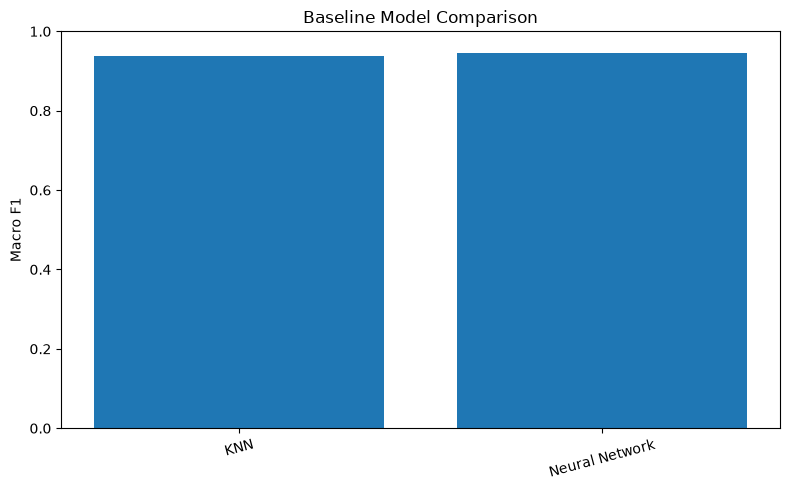

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    baseline_metrics["Model"],
    baseline_metrics["F1"],
)

plt.ylabel("Macro F1")
plt.title("Baseline Model Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [19]:
pca_plot = pca_comparison.copy()

pca_plot["Components"] = (
    pca_plot["Configuration"]
    .str.extract(r"PCA\((\d+)\)")[0]
    .astype(int)
)

pca_plot

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1,Components
0,PCA,KNN + PCA(2),KNN + PCA(2),0.859993,0.854555,0.851962,0.853106,2
1,PCA,KNN + PCA(4),KNN + PCA(4),0.888437,0.892038,0.887428,0.889034,4
2,PCA,KNN + PCA(6),KNN + PCA(6),0.926487,0.940418,0.937039,0.938658,6
3,PCA,KNN + PCA(8),KNN + PCA(8),0.925009,0.938876,0.935406,0.937091,8
4,PCA,KNN + PCA(10),KNN + PCA(10),0.925009,0.938876,0.935406,0.937091,10
5,PCA,KNN + PCA(12),KNN + PCA(12),0.925009,0.938876,0.935406,0.937091,12
6,PCA,KNN + PCA(14),KNN + PCA(14),0.925009,0.938876,0.935406,0.937091,14
7,PCA,KNN + PCA(16),KNN + PCA(16),0.925009,0.938876,0.935406,0.937091,16
8,PCA,Neural Network + PCA(2),Neural Network + PCA(2),0.865164,0.860399,0.857539,0.858443,2
9,PCA,Neural Network + PCA(4),Neural Network + PCA(4),0.897673,0.902797,0.896205,0.898614,4


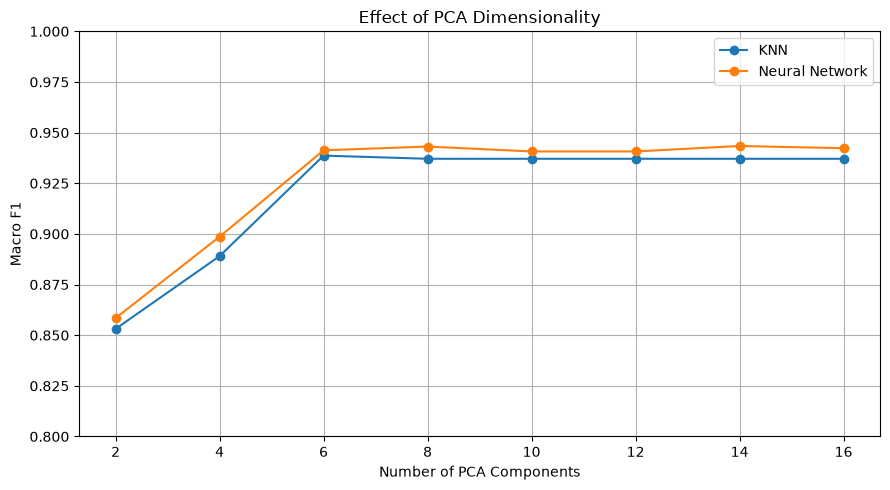

In [20]:
plt.figure(figsize=(9, 5))

for model in pca_plot["Model"].str.extract(
    r"^(KNN|Neural Network)"
)[0].dropna().unique():

    subset = pca_plot[
        pca_plot["Model"].str.startswith(model)
    ]

    plt.plot(
        subset["Components"],
        subset["F1"],
        marker="o",
        label=model,
    )

plt.xlabel("Number of PCA Components")
plt.ylabel("Macro F1")
plt.title("Effect of PCA Dimensionality")
plt.xticks(sorted(pca_plot["Components"].unique()))
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
lda_plot = lda_comparison.copy()

lda_plot["Components"] = (
    lda_plot["Configuration"]
    .str.extract(r"LDA\((\d+)\)")[0]
    .astype(int)
)

lda_plot

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1,Components
0,LDA,KNN + LDA(2),KNN + LDA(2),0.816033,0.834168,0.833872,0.833694,2
1,LDA,KNN + LDA(3),KNN + LDA(3),0.900997,0.914731,0.910717,0.912518,3
2,LDA,KNN + LDA(4),KNN + LDA(4),0.911341,0.924085,0.920318,0.921980,4
3,LDA,KNN + LDA(5),KNN + LDA(5),0.916882,0.930771,0.927713,0.929201,5
4,LDA,KNN + LDA(6),KNN + LDA(6),0.921315,0.934062,0.930931,0.932454,6
5,LDA,Neural Network + LDA(2),Neural Network + LDA(2),0.736239,0.804005,0.746585,0.743652,2
6,LDA,Neural Network + LDA(3),Neural Network + LDA(3),0.853713,0.887430,0.855359,0.867484,3
7,LDA,Neural Network + LDA(4),Neural Network + LDA(4),0.876616,0.892144,0.876072,0.882856,4
8,LDA,Neural Network + LDA(5),Neural Network + LDA(5),0.878094,0.909712,0.887210,0.896031,5
9,LDA,Neural Network + LDA(6),Neural Network + LDA(6),0.892132,0.920079,0.898133,0.907313,6


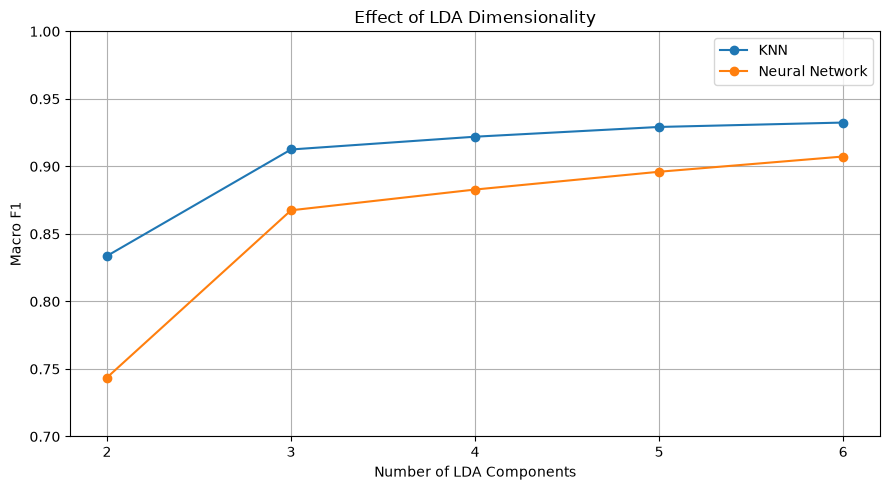

In [22]:
plt.figure(figsize=(9, 5))

for model in lda_plot["Model"].str.extract(
    r"^(KNN|Neural Network)"
)[0].dropna().unique():

    subset = lda_plot[
        lda_plot["Model"].str.startswith(model)
    ]

    plt.plot(
        subset["Components"],
        subset["F1"],
        marker="o",
        label=model,
    )

plt.xlabel("Number of LDA Components")
plt.ylabel("Macro F1")
plt.title("Effect of LDA Dimensionality")
plt.xticks(sorted(lda_plot["Components"].unique()))
plt.ylim(0.7, 1.0)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
pca_lda_plot = pd.concat(
    [
        pca_lda_knn_comparison,
        pca_lda_nn_comparison,
    ],
    ignore_index=True,
)

pca_lda_plot["Components"] = (
    pca_lda_plot["Configuration"]
    .str.extract(r"LDA\((\d+)\)")[0]
    .astype(int)
)

pca_lda_plot

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1,Components
0,PCA + LDA,KNN + PCA(8) + LDA(2),KNN + PCA(8) + LDA(2),0.844477,0.853794,0.848130,0.850591,2
1,PCA + LDA,KNN + PCA(8) + LDA(3),KNN + PCA(8) + LDA(3),0.911710,0.924893,0.920247,0.922355,3
2,PCA + LDA,KNN + PCA(8) + LDA(4),KNN + PCA(8) + LDA(4),0.917621,0.930852,0.927451,0.929066,4
3,PCA + LDA,KNN + PCA(8) + LDA(5),KNN + PCA(8) + LDA(5),0.921315,0.936106,0.932473,0.934212,5
4,PCA + LDA,KNN + PCA(8) + LDA(6),KNN + PCA(8) + LDA(6),0.929442,0.941495,0.938423,0.939892,6
5,PCA + LDA,Neural Network + PCA(8) + LDA(2),Neural Network + PCA(8) + LDA(2),0.854082,0.869329,0.858151,0.862622,2
6,PCA + LDA,Neural Network + PCA(8) + LDA(3),Neural Network + PCA(8) + LDA(3),0.920946,0.932470,0.929628,0.930839,3
7,PCA + LDA,Neural Network + PCA(8) + LDA(4),Neural Network + PCA(8) + LDA(4),0.921315,0.932675,0.931230,0.931852,4
8,PCA + LDA,Neural Network + PCA(8) + LDA(5),Neural Network + PCA(8) + LDA(5),0.925748,0.937187,0.936038,0.936581,5
9,PCA + LDA,Neural Network + PCA(8) + LDA(6),Neural Network + PCA(8) + LDA(6),0.931289,0.943255,0.941389,0.942286,6


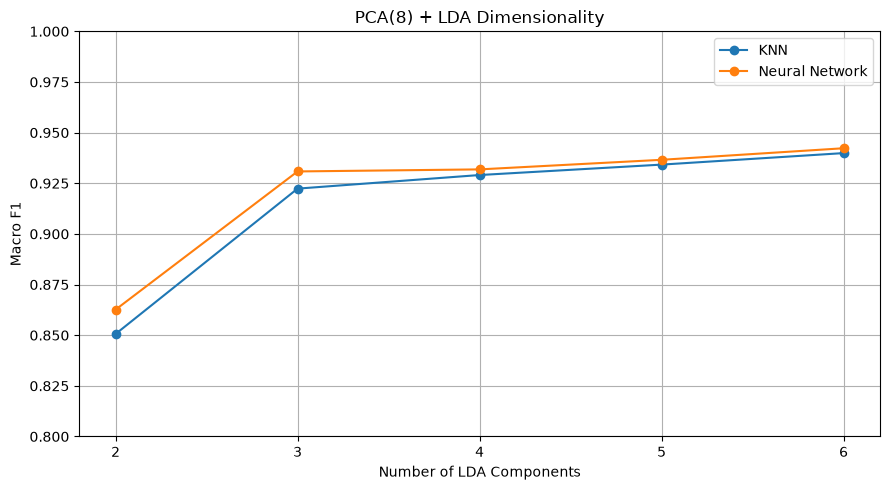

In [24]:
plt.figure(figsize=(9, 5))

for model in ["KNN", "Neural Network"]:

    subset = pca_lda_plot[
        pca_lda_plot["Model"].str.startswith(model)
    ]

    plt.plot(
        subset["Components"],
        subset["F1"],
        marker="o",
        label=model,
    )

plt.xlabel("Number of LDA Components")
plt.ylabel("Macro F1")
plt.title("PCA(8) + LDA Dimensionality")
plt.xticks(sorted(pca_lda_plot["Components"].unique()))
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

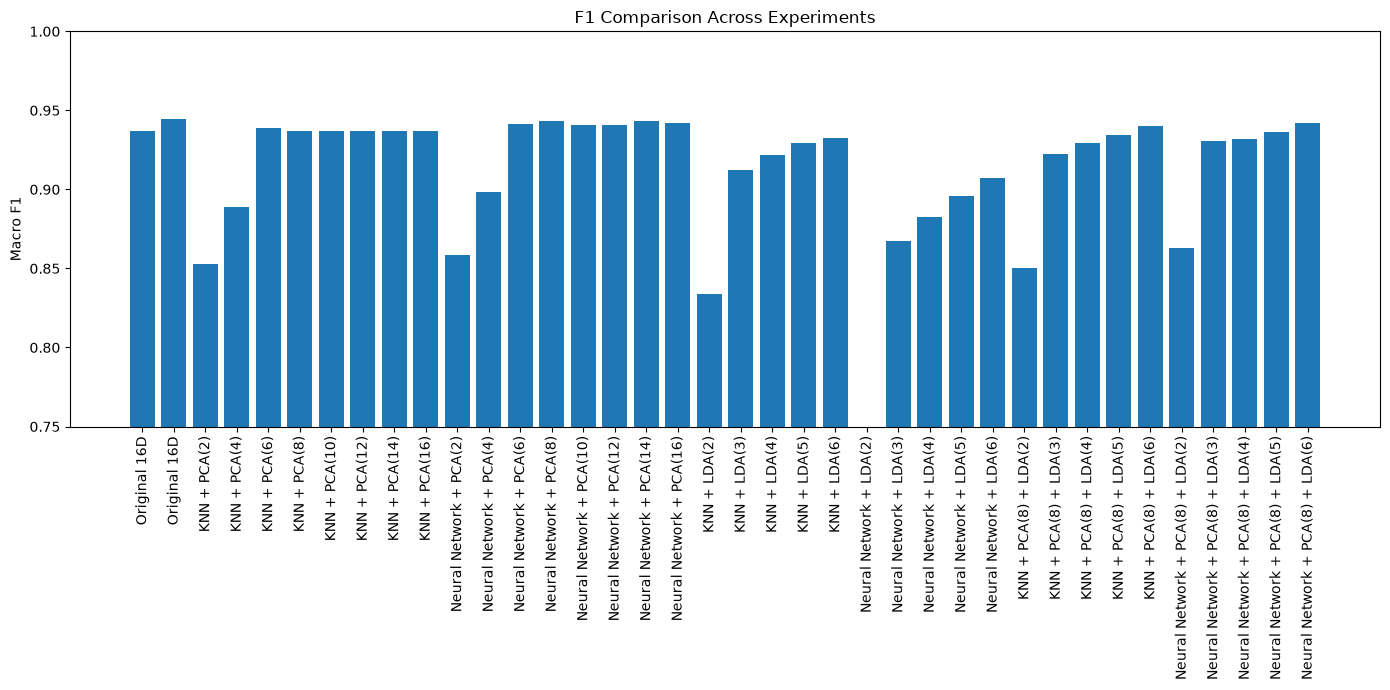

In [25]:
plt.figure(figsize=(14, 7))

plot_df = full_comparison.copy()

plt.bar(
    range(len(plot_df)),
    plot_df["F1"],
)

plt.xticks(
    range(len(plot_df)),
    plot_df["Configuration"],
    rotation=90,
)

plt.ylabel("Macro F1")
plt.title("F1 Comparison Across Experiments")
plt.ylim(0.75, 1.0)

plt.tight_layout()
plt.show()

In [26]:
full_comparison[
    [
        "Experiment",
        "Model",
        "Configuration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ]
]

,Experiment,Model,Configuration,Accuracy,Precision,Recall,F1
0,Baseline,KNN,Original 16D,0.925009,0.938876,0.935406,0.937091
1,Baseline,Neural Network,Original 16D,0.933875,0.945793,0.943841,0.944792
2,PCA,KNN + PCA(2),KNN + PCA(2),0.859993,0.854555,0.851962,0.853106
3,PCA,KNN + PCA(4),KNN + PCA(4),0.888437,0.892038,0.887428,0.889034
4,PCA,KNN + PCA(6),KNN + PCA(6),0.926487,0.940418,0.937039,0.938658
5,PCA,KNN + PCA(8),KNN + PCA(8),0.925009,0.938876,0.935406,0.937091
6,PCA,KNN + PCA(10),KNN + PCA(10),0.925009,0.938876,0.935406,0.937091
7,PCA,KNN + PCA(12),KNN + PCA(12),0.925009,0.938876,0.935406,0.937091
8,PCA,KNN + PCA(14),KNN + PCA(14),0.925009,0.938876,0.935406,0.937091
9,PCA,KNN + PCA(16),KNN + PCA(16),0.925009,0.938876,0.935406,0.937091


In [27]:
knn_tuning_sorted = knn_tuning_df.sort_values(
    "F1",
    ascending=False,
).reset_index(drop=True)

knn_tuning_sorted

,model,k,weights,Accuracy,Precision,Recall,F1
0,KNN,3,distance,0.919556,0.934234,0.932252,0.933181
1,KNN,3,uniform,0.919094,0.934157,0.932210,0.933105
2,KNN,5,uniform,0.920018,0.932818,0.931165,0.931874
3,KNN,5,distance,0.919556,0.932408,0.930825,0.931507
4,KNN,15,distance,0.918632,0.931050,0.928633,0.929461
5,KNN,7,distance,0.917707,0.930899,0.928462,0.929393
6,KNN,15,uniform,0.918632,0.931081,0.928208,0.929226
7,KNN,7,uniform,0.916782,0.930188,0.928060,0.928816
8,KNN,11,distance,0.916782,0.929723,0.927389,0.928257
9,KNN,9,distance,0.915395,0.928512,0.926763,0.927354


In [28]:
best_knn = knn_tuning_sorted.iloc[0]

print("Selected KNN configuration based on validation F1:")
print(f"k       = {int(best_knn['k'])}")
print(f"weights = {best_knn['weights']}")
print(f"Val F1  = {best_knn['F1']:.4f}")

Selected KNN configuration based on validation F1:
k       = 3
weights = distance
Val F1  = 0.9332


In [29]:
nn_tuning_sorted = nn_tuning_df.sort_values(
    "F1",
    ascending=False,
).reset_index(drop=True)

nn_tuning_sorted

,model,activation,learning_rate,batch_size,dropout_rate,Accuracy,Precision,Recall,F1
0,Neural Network,relu,0.010,64,0.2,0.924179,0.936172,0.933921,0.934866
1,Neural Network,relu,0.010,64,0.0,0.924179,0.934120,0.933595,0.933743
2,Neural Network,relu,0.010,32,0.2,0.922792,0.934474,0.931793,0.932882
3,Neural Network,relu,0.010,32,0.0,0.920018,0.931500,0.929760,0.930299
4,Neural Network,relu,0.001,32,0.0,0.914933,0.926988,0.924770,0.925608
5,Neural Network,relu,0.001,64,0.0,0.912159,0.924942,0.920434,0.922390
6,Neural Network,relu,0.001,32,0.2,0.909847,0.922597,0.919118,0.920484
7,Neural Network,sigmoid,0.010,32,0.0,0.903375,0.916619,0.912471,0.914363
8,Neural Network,relu,0.001,64,0.2,0.899676,0.916494,0.908939,0.911103
9,Neural Network,sigmoid,0.010,32,0.2,0.873786,0.883562,0.824384,0.837855


In [30]:
best_nn = nn_tuning_sorted.iloc[0]

print("Selected Neural Network configuration based on validation F1:")
print(f"activation    = {best_nn['activation']}")
print(f"learning_rate = {best_nn['learning_rate']}")
print(f"batch_size    = {int(best_nn['batch_size'])}")
print(f"dropout_rate  = {best_nn['dropout_rate']}")
print(f"Val F1        = {best_nn['F1']:.4f}")

Selected Neural Network configuration based on validation F1:
activation    = relu
learning_rate = 0.01
batch_size    = 64
dropout_rate  = 0.2
Val F1        = 0.9349
